## Einstellung

In [310]:
import os, sys
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(PROJECT_ROOT)

In [311]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.graphics.mosaicplot import mosaic

In [312]:
sns.set(style="whitegrid")
healthy_orange = '#EC6602'
healthy_orange_50 = '#F9B591'
healthy_orange_25 = '#FDDDCB'
siemens_petrol = '#009999'
siemens_petrol_50 = '#87D2D2'
custom_palette = [healthy_orange, siemens_petrol, healthy_orange_50, healthy_orange_25, siemens_petrol_50]
sns.set_palette(custom_palette)
RANDOM_SEED = 42

In [313]:
df = sns.load_dataset('penguins')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Univariate

### Numerisch

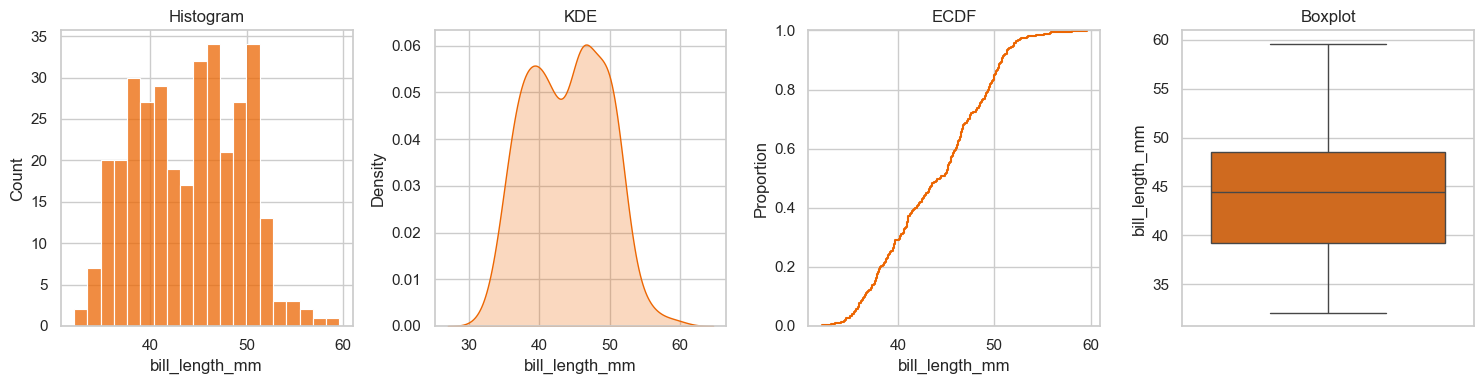

In [314]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
sns.histplot(df.bill_length_mm, bins=20, ax=axes[0]);
axes[0].set_title('Histogram')
sns.kdeplot(df.bill_length_mm, fill=True, ax=axes[1]);
axes[1].set_title('KDE')
sns.ecdfplot(df.bill_length_mm, ax=axes[2]);
axes[2].set_title('ECDF')
sns.boxplot(df.bill_length_mm, ax=axes[3]);
axes[3].set_title('Boxplot')
plt.tight_layout()
plt.show()

### Kategorial

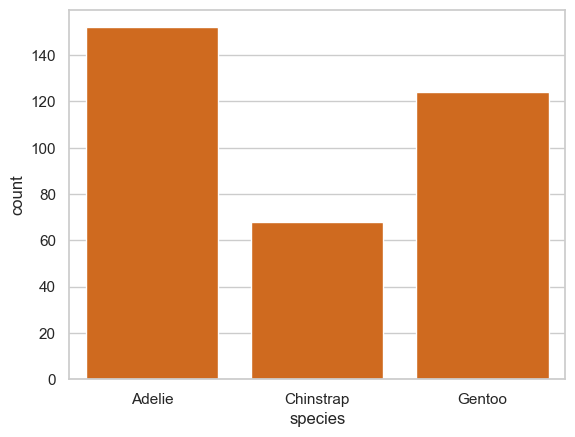

In [315]:
sns.countplot(x='species', data=df);

## Bivariate

### Numerisch x Numerisch

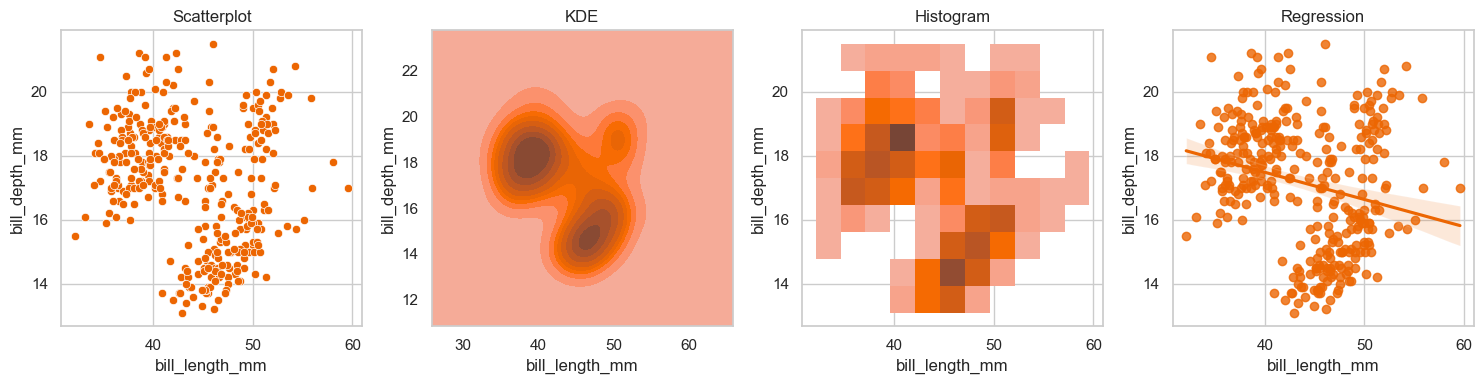

In [316]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
sns.scatterplot(x='bill_length_mm', y='bill_depth_mm', data=df, ax=axes[0]);
axes[0].set_title('Scatterplot')
sns.kdeplot(x='bill_length_mm', y='bill_depth_mm', data=df, ax=axes[1], fill=True, thresh=0);
axes[1].set_title('KDE')
sns.histplot(x='bill_length_mm', y='bill_depth_mm', data=df, ax=axes[2]);
axes[2].set_title('Histogram')
sns.regplot(x='bill_length_mm', y='bill_depth_mm', data=df, ax=axes[3]);
axes[3].set_title('Regression')
plt.tight_layout()
plt.show()

Jointplot with regression line


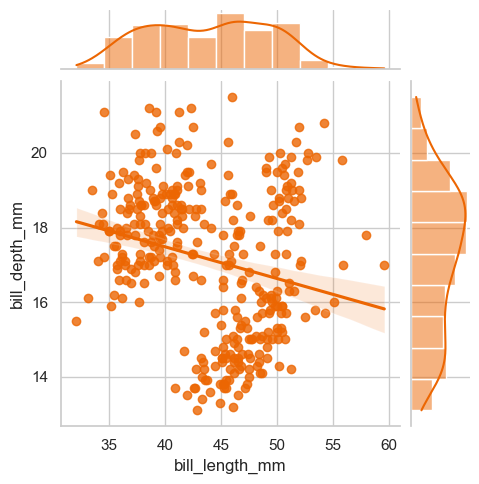

In [317]:
print("Jointplot with regression line")
sns.jointplot(x='bill_length_mm', y='bill_depth_mm', data=df, kind='reg', height=5);

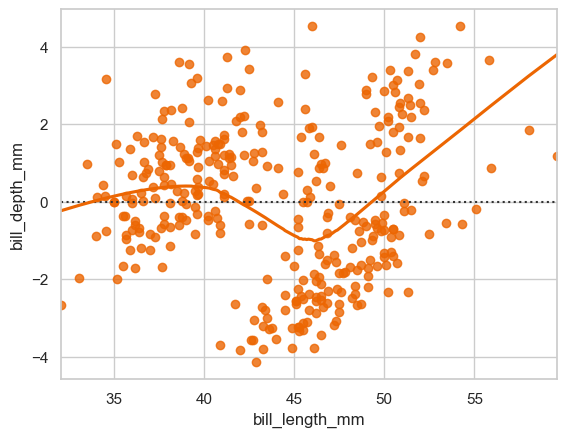

In [318]:
sns.residplot(x='bill_length_mm', y='bill_depth_mm', data=df, lowess=True);

Jointplot with KDE


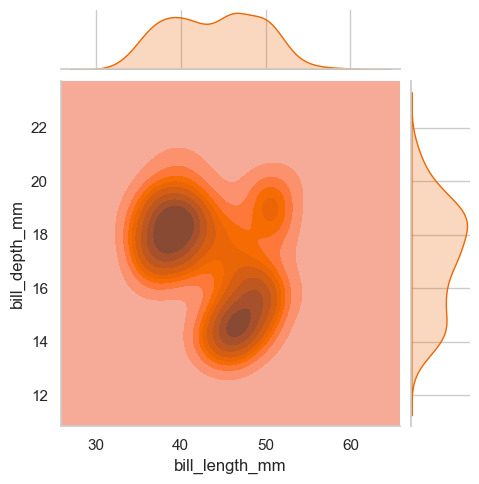

In [319]:
print("Jointplot with KDE")
sns.jointplot(x='bill_length_mm', y='bill_depth_mm', data=df, kind='kde', fill=True, thresh=0, height=5);

### Numerisch x Kategorial

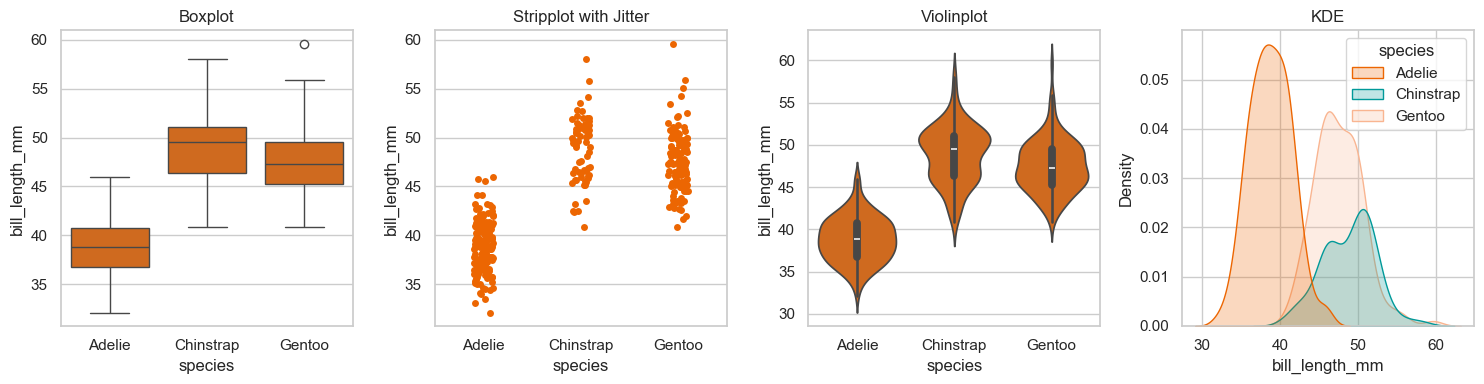

In [320]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
sns.boxplot(x='species', y='bill_length_mm', data=df, ax=axes[0]);
axes[0].set_title('Boxplot')
sns.stripplot(x='species', y='bill_length_mm', data=df, jitter=True, ax=axes[1]);
axes[1].set_title('Stripplot with Jitter')
sns.violinplot(x='species', y='bill_length_mm', data=df, ax=axes[2]);
axes[2].set_title('Violinplot')
sns.kdeplot(x='bill_length_mm', hue='species', data=df, fill=True, ax=axes[3]);
axes[3].set_title('KDE')
plt.tight_layout()
plt.show()

### Kategorial x Kategorial

Note: All graphs are based only on count.


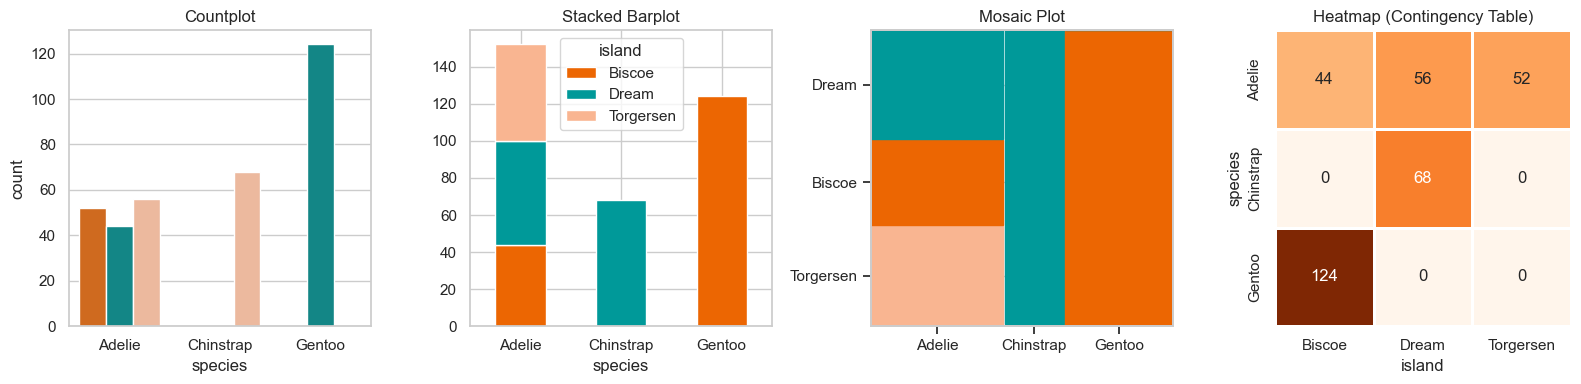

In [321]:
print("Note: All graphs are based only on count.")
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
sns.countplot(data=df, x='species', hue='island', ax=axes[0]);
axes[0].set_title('Countplot')
axes[0].get_legend().remove()
pd.crosstab(df.species, df.island).plot.bar(stacked=True, ax=axes[1]);
axes[1].set_title('Stacked Barplot')
axes[1].tick_params(axis='x', rotation=0)
island_colors = {
    'Biscoe': healthy_orange,
    'Dream': siemens_petrol,
    'Torgersen': healthy_orange_50
}
mosaic(df, ['species', 'island'], ax=axes[2], title='Mosaic Plot', labelizer=lambda _: '', properties=lambda k: {'color': island_colors[k[1]]});
ct = pd.crosstab(df.species, df.island)
sns.heatmap(ct, annot=True, cmap='Oranges', cbar=False, fmt='d', square=True, linewidths=1, ax=axes[3]);
axes[3].set_title('Heatmap (Contingency Table)')
plt.tight_layout()
plt.show()

## Multivariate

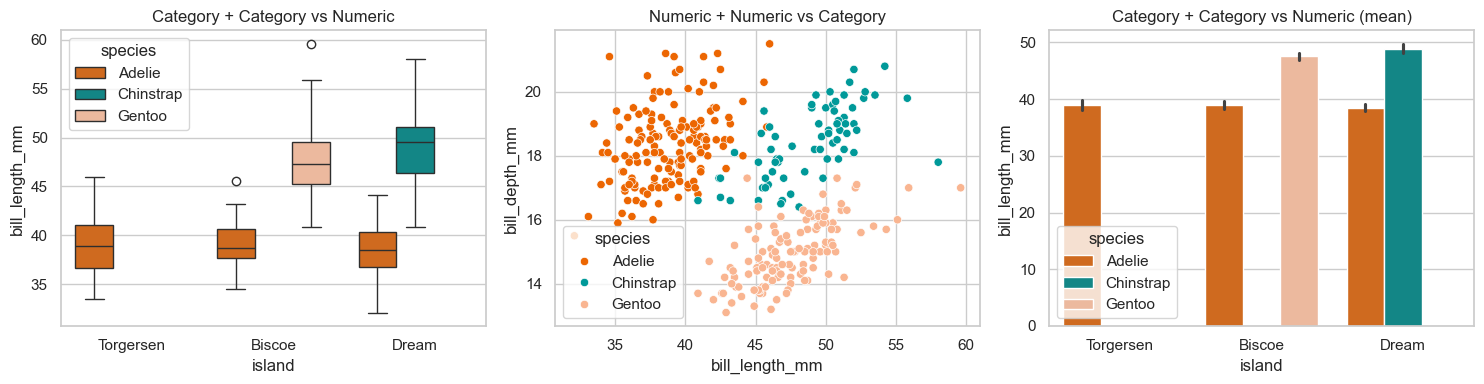

In [322]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(x='island', y='bill_length_mm', data=df, hue='species', ax=axes[0]);
axes[0].set_title('Category + Category vs Numeric')
sns.scatterplot(x='bill_length_mm', y='bill_depth_mm', data=df, hue='species', ax=axes[1]);
axes[1].set_title('Numeric + Numeric vs Category')
sns.barplot(x='island', y='bill_length_mm', data=df, hue='species', ax=axes[2], estimator='mean');
axes[2].set_title('Category + Category vs Numeric (mean)')
plt.tight_layout()
plt.show()

### Dimensionen:
Mehrere Dimensionen (Variablen) können in einem Plot dargestellt werden. Z.B. im unteren Plot sind ingesamt 6 Dimensionen:
1. x-Achse: `bill_length_mm`
2. y-Achse: `bill_depth_mm`
3. Farbe: `species`
4. Größe: `body_mass_g`
5. Grid x-Achse: `island`
6. Grid y-Achse: `sex`

So hat man viele Informationen auf einem Blick, das kann manchmal sehr hilfreich sein solange es nicht unübersichtlich wird. Z.B. hier sieht man hier deutlich dass verschiede Penguinarten einfach unteschieden werden. Zusätlich kann man noch eine Dimension "Style" (Marker Style) hinzufügen.

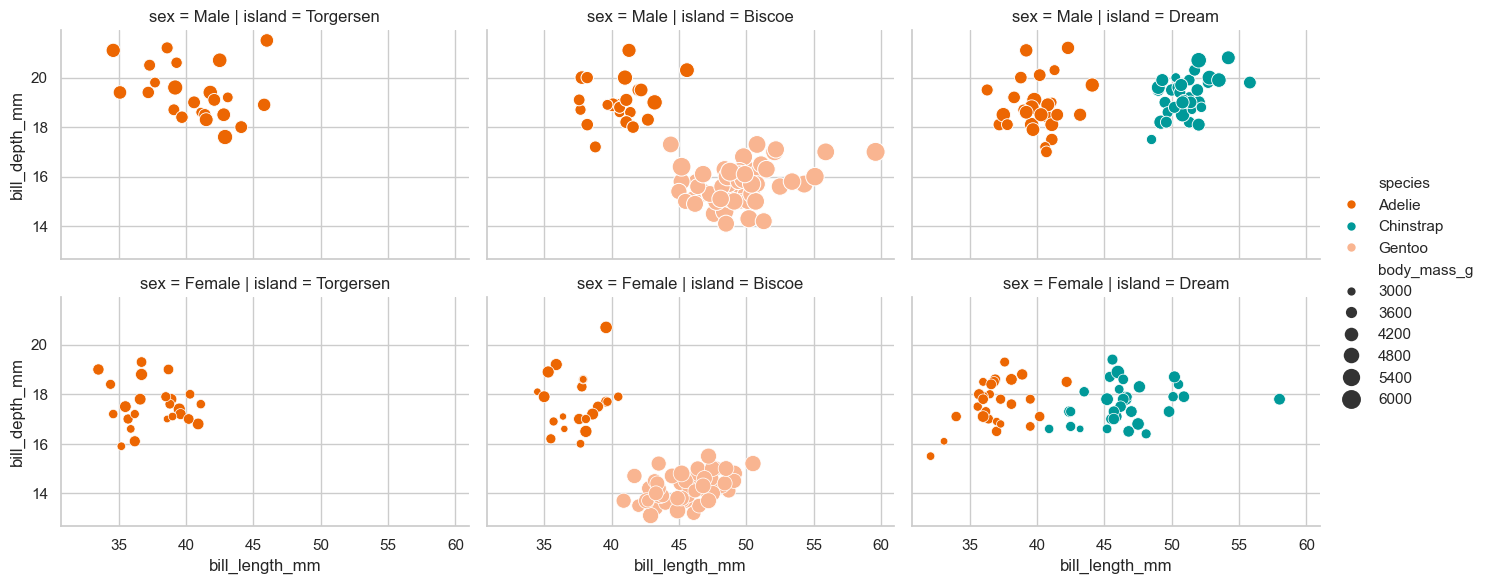

In [323]:
sns.relplot(x='bill_length_mm', 
            y='bill_depth_mm', 
            data=df, hue='species', 
            col='island', 
            height=3, 
            aspect=1.5, 
            size='body_mass_g', 
            sizes=(20, 200), 
            row='sex');

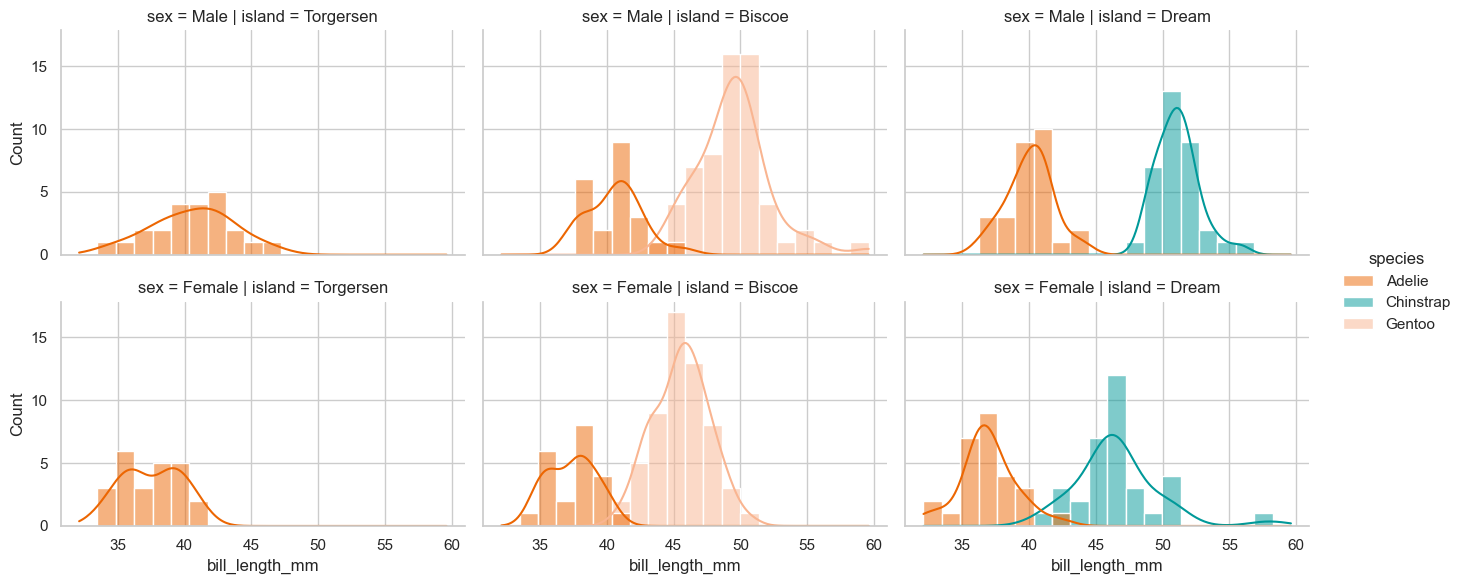

In [324]:
sns.displot(data=df, 
            x='bill_length_mm', 
            hue='species', 
            kind='hist', 
            kde=True, 
            col='island', 
            row='sex', 
            height=3, 
            aspect=1.5, 
            bins=20);

In [325]:
df['mass_cat'] = pd.cut(df.body_mass_g,
                        bins=[0, 4000, df.body_mass_g.max()],
                        labels=['Light', 'Heavy'])

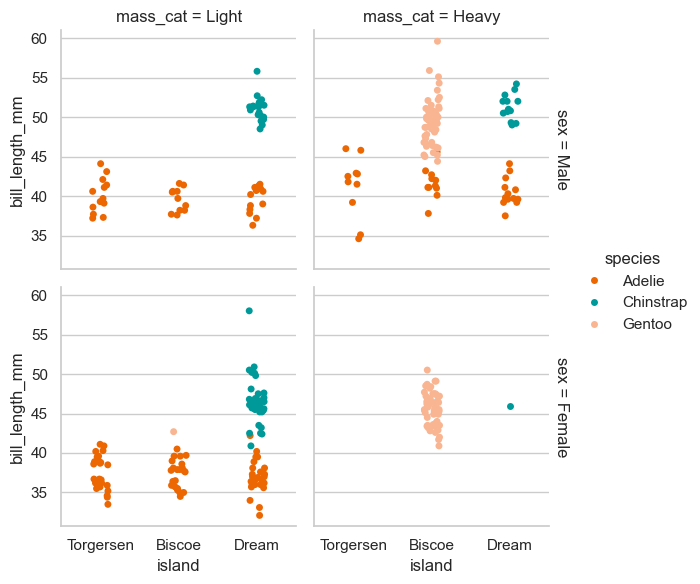

In [326]:
sns.catplot(x='island', y='bill_length_mm', data=df, hue='species', col='mass_cat', height=3, row='sex',margin_titles=True);

Scattermatrix (nur für Numerische Variablen)


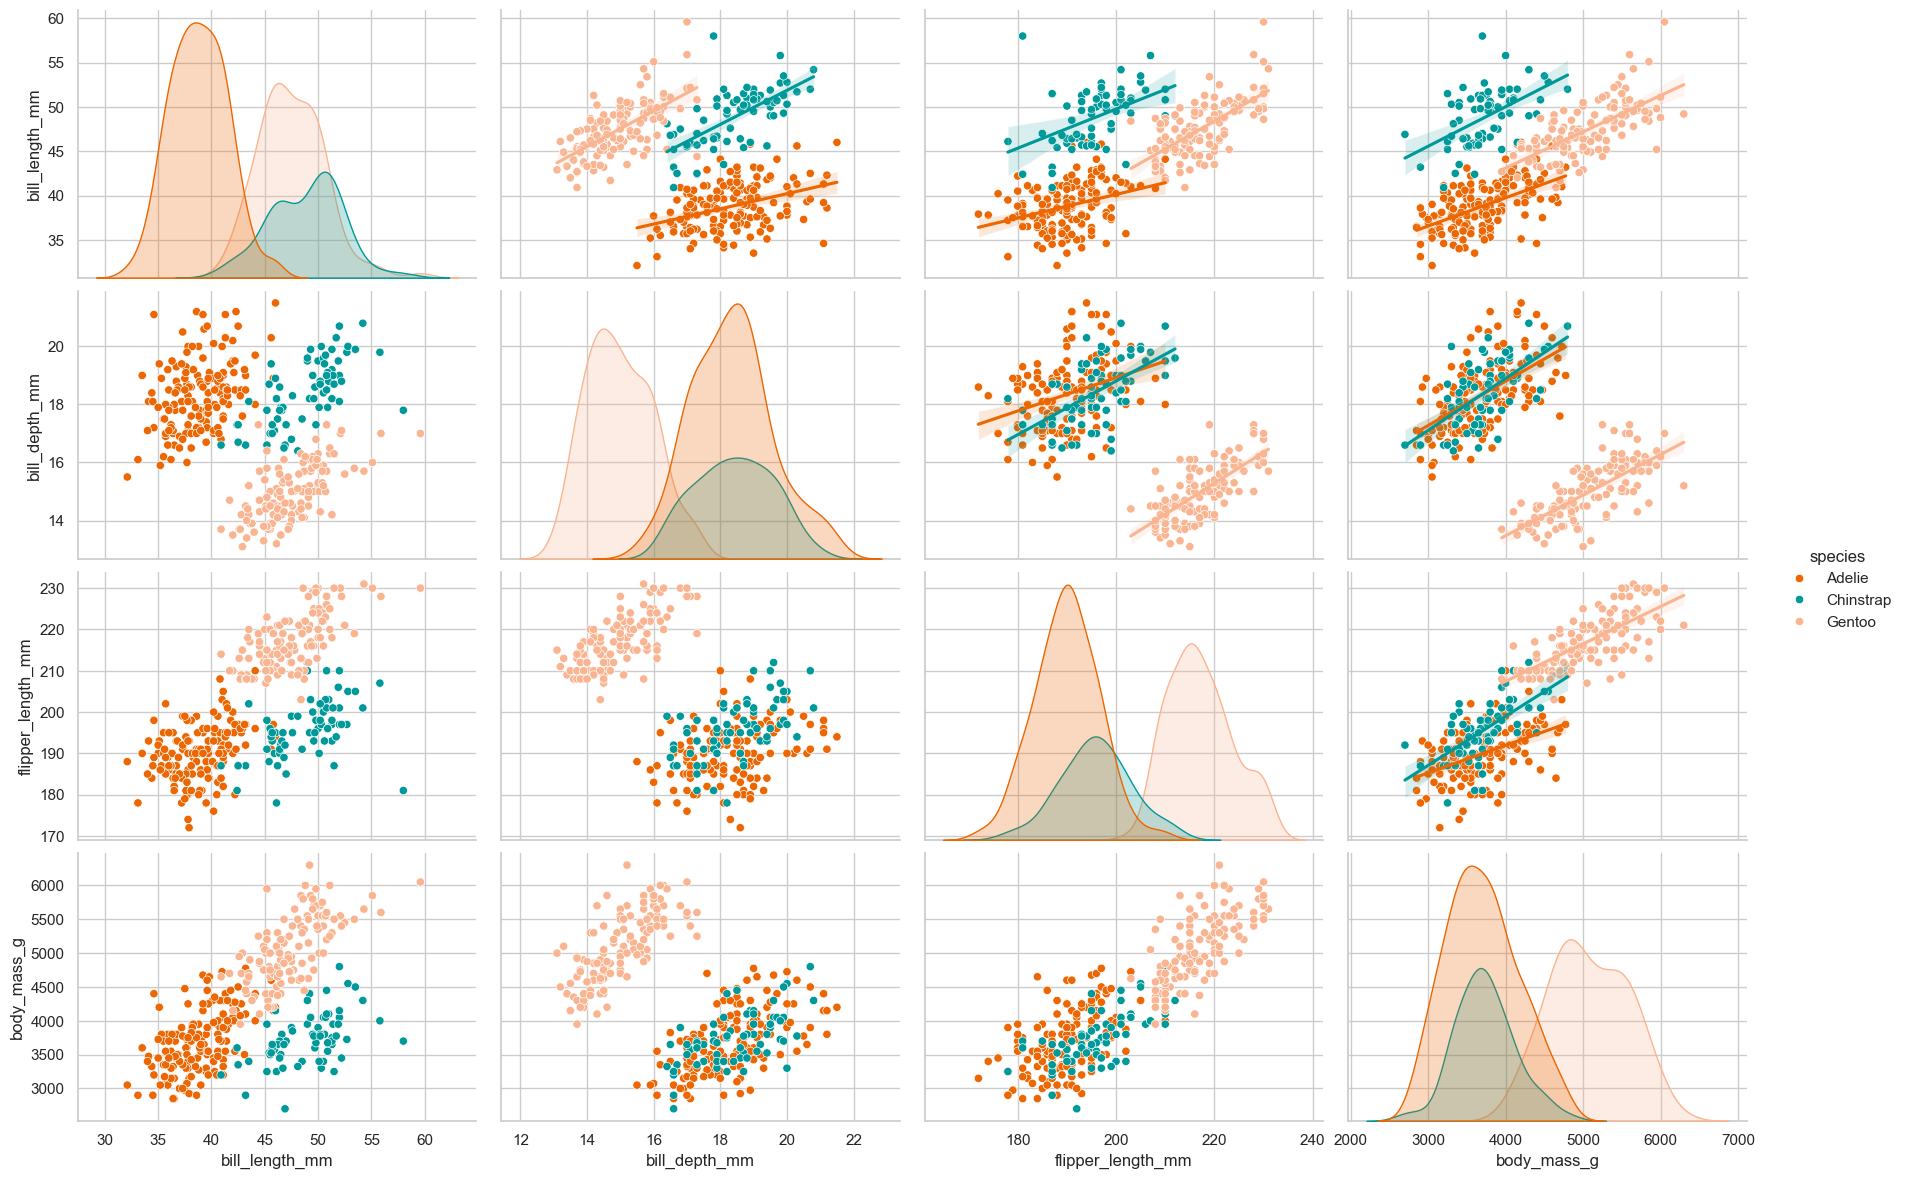

In [337]:
print("Scattermatrix (nur für Numerische Variablen)")
g = sns.pairplot(df, diag_kind='kde', hue='species', height=3, aspect=1.5);
g.map_upper(sns.regplot, scatter=False);

## Zeitreihen

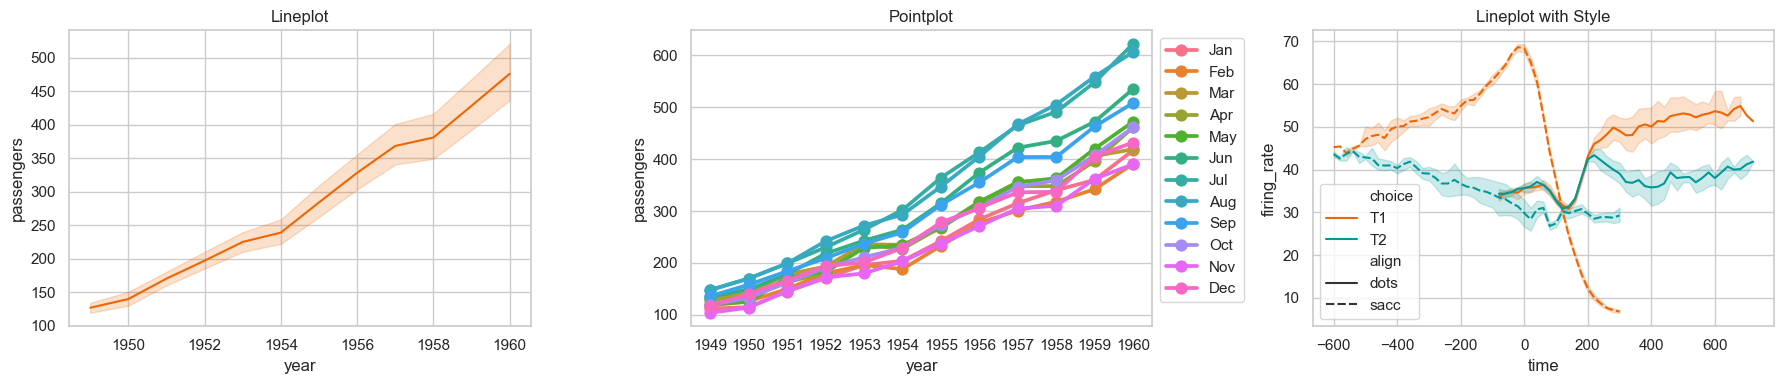

In [328]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
flights = sns.load_dataset('flights')
sns.lineplot(x='year', y='passengers', data=flights, ax=ax[0]);
ax[0].set_title('Lineplot')
sns.pointplot(data=flights, x='year', y='passengers', hue='month', ax=ax[1]);
ax[1].set_title('Pointplot')
ax[1].legend(bbox_to_anchor=(1, 1))
dots = sns.load_dataset('dots')
sns.lineplot(x='time', y='firing_rate', hue='choice', style='align', data=dots, ax=ax[2]);
ax[2].set_title('Lineplot with Style')
plt.tight_layout()
plt.show()

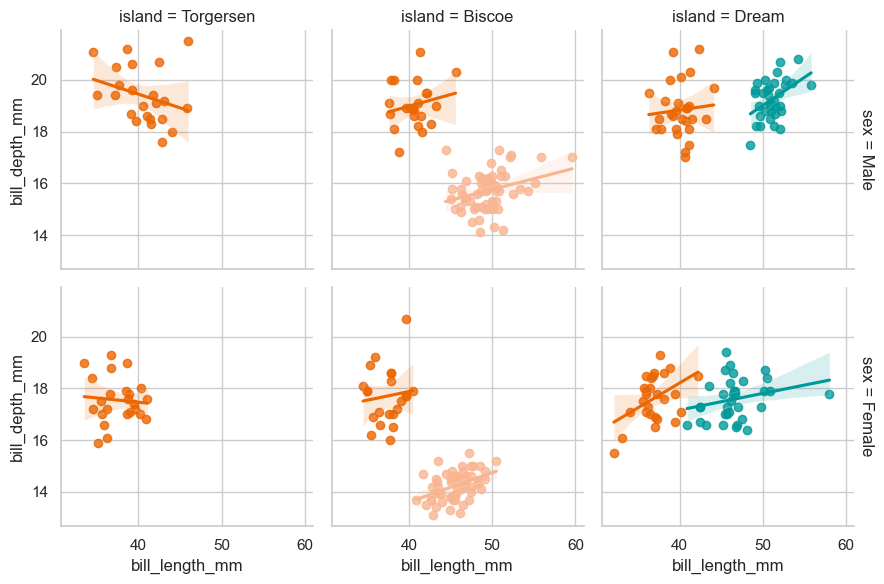

In [329]:
g = sns.FacetGrid(
    df, 
    col="island", 
    row="sex", 
    hue="species",
    margin_titles=True
)

g.map_dataframe(sns.regplot, x="bill_length_mm", y="bill_depth_mm");